# Predição de Cancelamento de Reservas Hoteleiras com Machine Learning para Apoio à Gestão de Receita

# 01 - Compreensão do Negócio e dos Dados

Neste primeiro notebook vou entender melhor o problema que quero resolver e também conhecer a estrutura da base de dados antes de começar qualquer etapa de limpeza ou modelagem.

O projeto será desenvolvido seguindo a metodologia CRISP-DM.

## 1. Compreensão do Negócio

O problema que quero estudar é o cancelamento de reservas de hotel. Quando uma reserva é cancelada, principalmente perto da data de chegada, isso pode dificultar o planejamento da ocupação e deixar quartos disponíveis que poderiam ter sido vendidos para outros clientes.

Meu objetivo é desenvolver um modelo que consiga estimar antecipadamente o risco de uma reserva ser cancelada.

A variável que quero prever é `is_canceled`:

- `0`: reserva não cancelada
- `1`: reserva cancelada

A ideia é utilizar somente informações que estariam disponíveis antes de conhecer o resultado final da reserva.

### Objetivo do projeto

Além de prever se uma reserva pode ser cancelada, quero analisar quais características estão mais relacionadas com esse comportamento e verificar se a probabilidade estimada pelo modelo pode ser útil para apoiar decisões do hotel.

Mais adiante, os modelos serão comparados com um baseline e avaliados utilizando métricas adequadas para classificação.

## 2. Compreensão dos Dados

### 2.1 Fonte dos dados

Estou utilizando o dataset Hotel Booking Demand. O arquivo está armazenado no repositório do projeto no GitHub.

Nesta etapa vou verificar o tamanho da base, as variáveis disponíveis, os tipos de dados, valores ausentes, possíveis inconsistências e a distribuição da variável que quero prever.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [3]:
DATA_URL = (
    "https://raw.githubusercontent.com/josepharroyoh/hotel-cancellation-ml/main/data/raw/hotel_booking.csv"
)

df = pd.read_csv(DATA_URL)

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


### 2.2 Dimensões da base

Primeiro vou verificar quantas reservas e quantas variáveis existem no dataset.

In [5]:
print(f"Número de registros: {df.shape[0]:,}")
print(f"Número de colunas: {df.shape[1]}")

Número de registros: 119,390
Número de colunas: 36


In [6]:
for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

01. hotel
02. is_canceled
03. lead_time
04. arrival_date_year
05. arrival_date_month
06. arrival_date_week_number
07. arrival_date_day_of_month
08. stays_in_weekend_nights
09. stays_in_week_nights
10. adults
11. children
12. babies
13. meal
14. country
15. market_segment
16. distribution_channel
17. is_repeated_guest
18. previous_cancellations
19. previous_bookings_not_canceled
20. reserved_room_type
21. assigned_room_type
22. booking_changes
23. deposit_type
24. agent
25. company
26. days_in_waiting_list
27. customer_type
28. adr
29. required_car_parking_spaces
30. total_of_special_requests
31. reservation_status
32. reservation_status_date
33. name
34. email
35. phone-number
36. credit_card


### 2.3 Visão geral das variáveis

Agora quero observar o tipo de cada coluna, quantos valores diferentes existem e se há dados faltantes.

In [7]:
variables_summary = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "valores_unicos": df.nunique(dropna=True),
    "valores_ausentes": df.isnull().sum(),
    "percentual_ausente": (df.isnull().mean() * 100).round(2)
})

variables_summary

,tipo,valores_unicos,valores_ausentes,percentual_ausente
hotel,object,2,0,0.00
is_canceled,int64,2,0,0.00
lead_time,int64,479,0,0.00
arrival_date_year,int64,3,0,0.00
arrival_date_month,object,12,0,0.00
arrival_date_week_number,int64,53,0,0.00
arrival_date_day_of_month,int64,31,0,0.00
stays_in_weekend_nights,int64,17,0,0.00
stays_in_week_nights,int64,35,0,0.00
adults,int64,14,0,0.00


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

Algumas variáveis aparecem como numéricas no arquivo, mas isso não significa necessariamente que serão tratadas como números no modelo.

Por exemplo, `agent` e `company` representam códigos de identificação e fazem mais sentido como categorias. Essa diferença será considerada na etapa de preparação dos dados.

In [9]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Colunas numéricas: {len(numerical_cols)}")
print(numerical_cols)

print(f"\nColunas categóricas/texto: {len(categorical_cols)}")
print(categorical_cols)

Colunas numéricas: 20
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Colunas categóricas/texto: 16
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date', 'name', 'email', 'phone-number', 'credit_card']


### 2.4 Valores ausentes

Uma das primeiras coisas que quero verificar é quais colunas possuem dados faltantes e qual é a proporção desses valores.

In [10]:
missing = pd.DataFrame({
    "valores_ausentes": df.isnull().sum(),
    "percentual": df.isnull().mean() * 100
})

missing = (
    missing[missing["valores_ausentes"] > 0]
    .sort_values("percentual", ascending=False)
)

missing.round(2)

,valores_ausentes,percentual
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


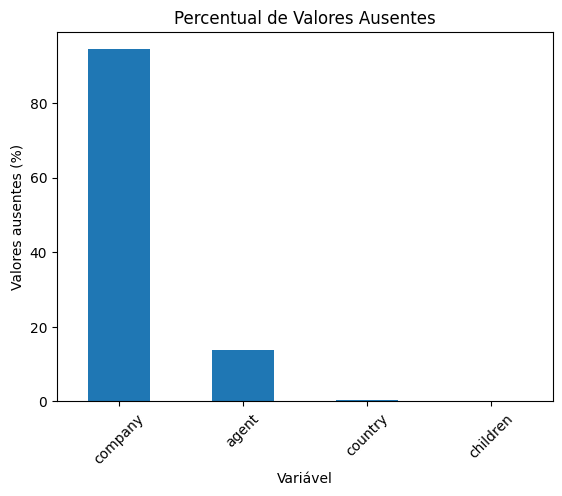

In [11]:
missing["percentual"].plot(kind="bar")

plt.title("Percentual de Valores Ausentes")
plt.xlabel("Variável")
plt.ylabel("Valores ausentes (%)")
plt.xticks(rotation=45)

plt.show()

A coluna `company` chama atenção porque possui mais de 94% de valores ausentes. Por enquanto não vou remover nenhuma variável, mas provavelmente essa coluna terá pouca utilidade para o modelo.

A coluna `agent` também possui uma quantidade relevante de valores ausentes e precisará ser analisada com mais cuidado.

### 2.5 Registros duplicados

Também vou verificar se existem linhas completamente repetidas na base.

In [12]:
duplicates = df.duplicated().sum()

print(f"Registros duplicados encontrados: {duplicates:,}")

Registros duplicados encontrados: 0


O dataset possui quatro colunas relacionadas à identificação do cliente:

- `name`
- `email`
- `phone-number`
- `credit_card`

Essas informações não são necessárias para prever o cancelamento e também podem fazer com que reservas parecidas sejam consideradas diferentes somente por causa desses identificadores.

Por isso quero verificar novamente as duplicatas sem considerar essas quatro colunas.

In [17]:
identity_cols = [
    "name",
    "email",
    "phone-number",
    "credit_card"
]

df_without_identity = df.drop(columns=identity_cols)

duplicates_without_identity = df_without_identity.duplicated().sum()

print( f"Registros coincidentes sem as colunas de identificação:{duplicates_without_identity:,}")

Registros coincidentes sem as colunas de identificação:31,994


Depois de retirar apenas as colunas de identificação aparecem 31.994 registros coincidentes.

Mesmo assim, não vou eliminar essas linhas automaticamente, porque o dataset não possui um identificador original da reserva. Duas reservas diferentes podem ter exatamente as mesmas características.

Vou deixar essa decisão para a etapa de preparação dos dados.

### 2.6 Distribuição da variável alvo

A variável `is_canceled` será usada como alvo do modelo. Quero verificar quantas reservas foram canceladas e quantas não foram.

In [19]:
target_distribution = pd.DataFrame({
    "quantidade": df["is_canceled"].value_counts().sort_index(),
    "percentual": (df["is_canceled"].value_counts(normalize=True).sort_index() * 100).round(2)
})

target_distribution.index = [ "Não cancelada (0)", "Cancelada (1)"]

target_distribution

,quantidade,percentual
Não cancelada (0),75166,62.96
Cancelada (1),44224,37.04


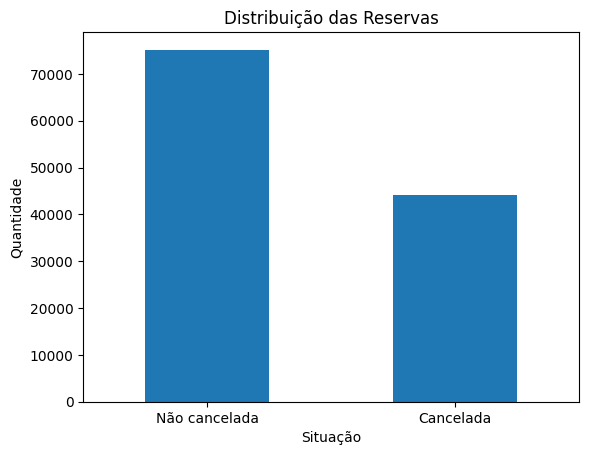

In [21]:
counts = df["is_canceled"].value_counts().sort_index()

counts.plot(kind="bar")
plt.title("Distribuição das Reservas")
plt.xlabel("Situação")
plt.ylabel("Quantidade")
plt.xticks([0, 1],["Não cancelada", "Cancelada"], rotation=0)
plt.show()

A classe de reservas não canceladas é maior, representando aproximadamente 63% dos dados, enquanto cerca de 37% das reservas foram canceladas.

Não considero esse desbalanceamento extremo, mas vou levar essa diferença em conta quando avaliar os modelos. Por isso não pretendo analisar somente a acurácia.

### 2.7 Verificação de possível Data Leakage

Como quero prever o cancelamento antes de conhecer o resultado final da reserva, preciso tomar cuidado com variáveis que podem conter informações que só aparecem depois do cancelamento ou da estadia.

A primeira variável que quero verificar é `reservation_status`.

In [ ]:
pd.crosstab(df["reservation_status"], df["is_canceled"], margins=True)

is_canceled,0,1,All
reservation_status,,,
Canceled,0,43017,43017
Check-Out,75166,0,75166
No-Show,0,1207,1207
All,75166,44224,119390


Nesse caso ficou claro que `reservation_status` revela praticamente a resposta que quero prever.

Quando o status é `Check-Out`, a reserva não foi cancelada. Quando aparece `Canceled` ou `No-Show`, `is_canceled` é igual a 1.

Por isso essa variável não poderá ser usada como entrada do modelo. O mesmo cuidado será aplicado à coluna `reservation_status_date`, porque ela também está relacionada ao resultado final da reserva.

Também existem algumas variáveis que precisam ser analisadas de acordo com o momento em que a previsão será feita:

- `assigned_room_type`
- `booking_changes`
- `days_in_waiting_list`

Essas informações podem mudar depois da criação inicial da reserva. Antes de utilizá-las no modelo, vou verificar se elas estariam realmente disponíveis no momento da previsão.

### 2.8 Quantidade de categorias

Agora quero observar quantos valores diferentes existem nas principais variáveis categóricas. Isso será importante mais adiante para decidir como fazer a codificação.

In [ ]:
categorical_overview = pd.DataFrame({"valores_unicos": df[categorical_cols].nunique()}).sort_values("valores_unicos", ascending=False)

categorical_overview

,valores_unicos
phone-number,119390
email,115889
name,81503
credit_card,9000
reservation_status_date,926
country,177
assigned_room_type,12
arrival_date_month,12
reserved_room_type,10
market_segment,8


As colunas de identificação possuem uma quantidade muito alta de valores únicos, o que reforça que não fazem sentido como variáveis de entrada para o modelo.

Também percebi que `country` possui muitas categorias e provavelmente precisará de atenção durante a etapa de codificação.

### 2.9 Verificação inicial de possíveis inconsistências

Além dos valores ausentes, quero verificar alguns valores que podem representar erros ou situações pouco comuns.

Uma das variáveis que chamou atenção foi `adr`, que representa a tarifa média diária da reserva.

In [26]:
df["adr"].describe()

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

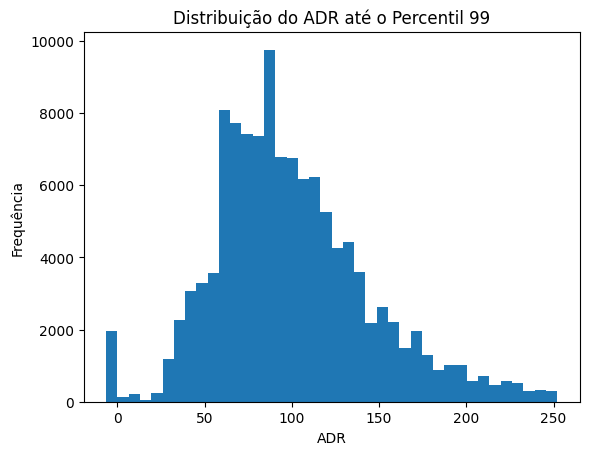

In [ ]:
adr_limit = df["adr"].quantile(0.99)
df.loc[df["adr"] <= adr_limit, "adr"].plot(kind="hist", bins=40)

plt.title("Distribuição do ADR até o Percentil 99")
plt.xlabel("ADR")
plt.ylabel("Frequência")
plt.show()

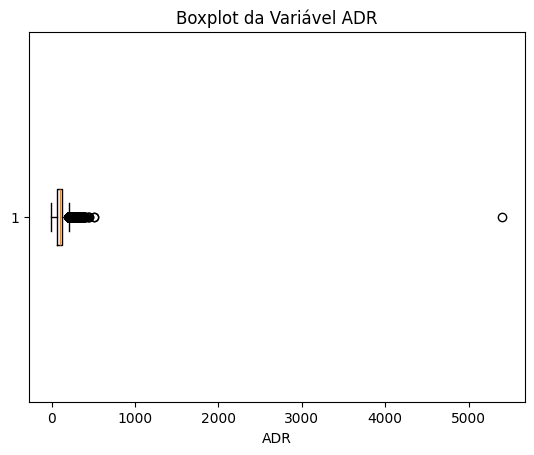

In [ ]:
plt.boxplot(df["adr"].dropna(), vert=False)

plt.title("Boxplot da Variável ADR")
plt.xlabel("ADR")
plt.show()

O `adr` possui um valor mínimo negativo (-6,38) e também alguns valores muito acima da maior parte das reservas, incluindo um máximo de 5400.

Ainda não vou excluir esses valores. Na etapa de preparação vou verificar se são erros, casos válidos ou se precisam de algum tratamento específico.

In [ ]:
total_guests = (df["adults"] + df["children"].fillna(0)+ df["babies"])

total_nights = (df["stays_in_weekend_nights"] + df["stays_in_week_nights"])

print("Reservas com zero hóspedes:",(total_guests == 0).sum())
print("Reservas com zero noites:",(total_nights == 0).sum())

Reservas com zero hóspedes: 180
Reservas com zero noites: 715


Também encontrei 180 registros sem hóspedes e 715 registros com zero noites de estadia.

Esses casos podem ter alguma explicação dentro do sistema de reservas, então prefiro investigá-los melhor antes de simplesmente removê-los.

### 2.10 Estatísticas das variáveis numéricas

Por último, vou observar um resumo das variáveis numéricas para identificar valores muito altos, negativos ou distribuições que precisem de mais atenção.

In [30]:
df[numerical_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.37,0.48,0.00,0.00,0.00,1.0,1.0
lead_time,119390.0,104.01,106.86,0.00,18.00,69.00,160.0,737.0
arrival_date_year,119390.0,2016.16,0.71,2015.00,2016.00,2016.00,2017.0,2017.0
arrival_date_week_number,119390.0,27.17,13.61,1.00,16.00,28.00,38.0,53.0
arrival_date_day_of_month,119390.0,15.80,8.78,1.00,8.00,16.00,23.0,31.0
stays_in_weekend_nights,119390.0,0.93,1.00,0.00,0.00,1.00,2.0,19.0
stays_in_week_nights,119390.0,2.50,1.91,0.00,1.00,2.00,3.0,50.0
adults,119390.0,1.86,0.58,0.00,2.00,2.00,2.0,55.0
children,119386.0,0.10,0.40,0.00,0.00,0.00,0.0,10.0
babies,119390.0,0.01,0.10,0.00,0.00,0.00,0.0,10.0


## 3. Principais pontos encontrados

Depois dessa primeira análise, consegui entender melhor a estrutura da base e também encontrei alguns pontos que vou precisar tratar antes da modelagem.

Os principais foram:

- a variável alvo possui aproximadamente 63% de reservas não canceladas e 37% canceladas;
- `company` possui mais de 94% de valores ausentes;
- `agent` também apresenta uma quantidade relevante de valores ausentes;
- `reservation_status` e `reservation_status_date` não poderão ser usadas porque revelam informações do resultado final da reserva;
- `name`, `email`, `phone-number` e `credit_card` são identificadores que não fazem sentido para a previsão;
- existem valores de `adr` que precisam ser investigados;
- existem reservas com zero hóspedes e também com zero noites;
- alguns registros ficam iguais depois da retirada das colunas de identificação, mas não vou considerá-los duplicados automaticamente.

No próximo notebook vou fazer uma análise exploratória mais focada em entender quais características estão relacionadas com o cancelamento.